In [1]:
import sys
import argparse
import os
import numpy as np
import anndata
import statsmodels.api as sm
import statsmodels.formula.api as smf
import tqdm
import pandas as pd



import anndata
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy
from matplotlib.pyplot import rc_context




In [2]:

# --- INIT ---

# which data to use
head_folder = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint'
hvg_to_use = 'transformed_X_outlier_variance'
cluster_resolution = 0.05

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# settings
min_prop = 1e-6




In [3]:
# --- LOAD ADATA ---

adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [5]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

descriptions = list(adata.obs['description'].unique())
clusters = list(adata.obs['cluster'].unique())

print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)




Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3, 4, 6, 5]


In [6]:
# --- LIMIT ADATA TO GENES THAT MEET MINIMUM PSEUDOBULK COUNT THRESHOLD ---


# ** get gene pseudobulk counts
adata.var['pseudobulk_count'] = np.array(np.sum(adata.X,axis=0)).flatten()

# ** get the number of cells in the smallest cell type
smallest_cell_type_adata = adata[adata.obs['cluster'] == np.max(clusters)]

# ** get pseudobulk cutoff **
pseudobulk_threshold = min_prop * np.sum(smallest_cell_type_adata.obs['lib_size'])

# ** limit adata to this **
adata = adata[:,adata.var['pseudobulk_count'] >= pseudobulk_threshold]


adata


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 145271 × 26120
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'pseudobulk_count'
    obsm: 'X_scVI', 'X_scVI_umap'

In [7]:
# --- IDENTIFY GENES MEETING THE MINIMUM PROP IN EACH CLUSTER / CONDITION COMBO ---

import warnings
warnings.filterwarnings('ignore')

genes_to_est = set()
for i, description in enumerate(descriptions):
    for j, cluster in enumerate(clusters):
        print("Description: %s; Cluster: %s" % (i,j))
            
        description,cluster = descriptions[0], clusters[0]
        cluster_condition_adata = adata[(adata.obs['cluster'] == cluster) & (adata.obs['description'] == description)]
        cluster_condition_adata.var['prop'] = np.array(np.sum(cluster_condition_adata.X,axis=0)).flatten()  / np.sum(cluster_condition_adata.obs['lib_size'])
        cluster_condition_adata = cluster_condition_adata[:,cluster_condition_adata.var['prop'] >= min_prop]
        genes_to_est.update(list(cluster_condition_adata.var_names))

# make it a list
genes_to_est = list(genes_to_est)



Description: 0; Cluster: 0


Trying to set attribute `.var` of view, copying.


Description: 0; Cluster: 1


Trying to set attribute `.var` of view, copying.


Description: 0; Cluster: 2


...

Trying to set attribute `.var` of view, copying.


Description: 5; Cluster: 5


Trying to set attribute `.var` of view, copying.


Description: 5; Cluster: 6


Trying to set attribute `.var` of view, copying.


In [8]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/point_est_harmonic_reg' % clustering_folder
if not os.path.exists(reg_head_folder):
    os.makedirs(reg_head_folder)


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    if not os.path.exists(cluster_reg_folder):
        os.makedirs(cluster_reg_folder)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)
        if not os.path.exists(cluster_description_reg_folder):
            os.makedirs(cluster_description_reg_folder)
            
        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [9]:
# --- WRITE OUT THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout,"wb") as file_obj:
    file_obj.write("\n".join(genes_to_est).encode())




In [10]:
# --- DEFINE FUNCTION TO PREP REGRESSION FOR A GIVEN GENE ---


def prep_regression_df(adata,gene_index):


    # ** get expression as a dense matrix **
    try:
        gene_X = np.array(adata.X[:,gene_index].todense())
    except:
        gene_X = np.array(adata.X[:,gene_index])
    try:
        gene_X = gene_X.flatten()
    except:
        pass


    # ** create gene_df to run regressions **


    # add expression and covariates to df
    gene_df = pd.DataFrame()
    gene_df["X"] = gene_X

    # log lib size
    try:
        gene_df["log_L"] = np.array(adata.obs['log_L'])
    except:
        pass

    # harmonic coefficients
    try:
        gene_df['cos'] = np.array(adata.obs['cos'])
    except:
        pass
    try:
        gene_df['sin'] = np.array(adata.obs['sin'])
    except:
        pass

    # phase
    try:
        gene_df['phase'] = np.array(adata.obs['phase'])
    except:
        pass

    # batch
    try:
        gene_df['batch'] = np.array(adata.obs['batch'])
    except:
        pass

    # sex
    try:
        gene_df['sex'] = np.array(adata.obs['sex'])
    except:
        pass

    # misaignment
    try:
        gene_df['misaligned'] = np.array(adata.obs['misaligned'])
    except:
        pass

    # bmal1_ko
    try:
        gene_df['bmal1_ko'] = np.array(adata.obs['bmal1_ko'])
    except:
        pass

    # mesor
    gene_df['mu'] = 1

    return gene_df



In [11]:
# --- FUNCTION TO PREP ADATA FOR REGRESSION ---

def prep_adata_for_regression(adata):
    
    adata.var['prop'] = np.array(np.sum(adata.X,axis=0)).flatten()  / np.sum(adata.obs['lib_size'])
    adata.obs['log_L'] = np.log(adata.obs['lib_size'])
    adata.obs['theta'] = (np.array(adata.obs['zt'] / 24.0)) * 2 * np.pi
    adata.obs['cos'] = np.cos(np.array(adata.obs['theta']))
    adata.obs['sin'] = np.sin(np.array(adata.obs['theta']))
    return adata
    

In [15]:
# --- FIT ---

failed_list = []

print("TEMPORARILY SUBSETTING CLUSTERS TO THE LAST 2")
for cluster in clusters[-2:]:
    for description in descriptions:
        
        try:
        
            print("----------------")
            print("Cluster %s; Description %s" % (cluster,description))


            # ** get cluster, condition adata **
            cluster_condition_adata = adata[(adata.obs['cluster'] == cluster) & (adata.obs['description'] == description)]
            cluster_condition_adata = cluster_condition_adata[:,genes_to_est]
            # cluster_condition_adata = cluster_condition_adata[:,['Dbp','Arntl','Myh11']]


            # ** prep for regression **
            cluster_condition_adata = prep_adata_for_regression(cluster_condition_adata)
            log_L = np.array(cluster_condition_adata.obs['log_L'])

            # ** set the formula **
            formula = "X ~ mu + cos + sin - 1"

            # ** init lists to store parameters **
            mesor_list,amp_list,acrophase_list,was_fit_list,ll_list = [], [], [], [],[]

            # ** fit **
            for gene_index in tqdm.tqdm(range(0,cluster_condition_adata.shape[1])):

                # ** if the number of transcripts detected for the gene is zero, just continue on **
                if cluster_condition_adata[:,gene_index].var['prop'].item() == 0:
                    mesor_list.append(None)
                    amp_list.append(None)
                    acrophase_list.append(None)
                    was_fit_list.append(False)
                    ll_list.append(None)
                    continue

                # ** prepare the DF for regression **
                gene_df = prep_regression_df(cluster_condition_adata,gene_index)

                # ** init model **
                mean_model = smf.glm(formula = formula, data = gene_df, family=sm.families.Poisson(), offset = log_L)

                # ** fit **
                mean_res = mean_model.fit()

                # ** write out the fit for each gene as a pkl object **


                # ** get the coefficients and add to list **

                # get coef
                gene_mesor,gene_cos,gene_sin=mean_res.params
                gene_amp = (gene_cos ** 2 + gene_sin ** 2) ** 0.5
                gene_acrophase = np.arctan2(gene_sin,gene_cos)

                # add to list
                mesor_list.append(gene_mesor)
                amp_list.append(gene_amp)
                acrophase_list.append(gene_acrophase)
                was_fit_list.append(True)
                ll_list.append(mean_res.llf)

            # ** make the gene param df for the cluster - condition **
            gene_param_df = pd.DataFrame()
            gene_param_df['gene'] = cluster_condition_adata.var_names
            gene_param_df['mesor'] = mesor_list
            gene_param_df['amp'] = amp_list
            gene_param_df['acrophase'] = acrophase_list
            gene_param_df['was_fit'] = was_fit_list
            gene_param_df['ll'] = ll_list
            gene_param_df = gene_param_df.set_index("gene")

            # ** write results out **

            # get folder out
            folder_out = cluster_description_folder_out_dict[cluster][description]

            # write out gene param df
            fileout = '%s/gene_param_df.tsv' % folder_out
            gene_param_df.to_csv(fileout,sep='\t')
            
        except:
            
            failed = '%s_%s' % (cluster,description)
            failed_list.append(failed)


Trying to set attribute `.var` of view, copying.
  0%|          | 28/12111 [00:00<00:44, 268.83it/s]

TEMPORARILY SUBSETTING CLUSTERS TO THE LAST 2
----------------
Cluster 6; Description male aligned bmal1-ko


100%|██████████| 12111/12111 [00:37<00:00, 321.70it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 43/12111 [00:00<00:30, 394.67it/s]

----------------
Cluster 6; Description male misaligned bmal1-control


  1%|          | 67/12111 [00:00<00:32, 369.64it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 29/12111 [00:00<00:47, 253.17it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 0/12111 [00:00<?, ?it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 0/12111 [00:00<?, ?it/s]

...

100%|██████████| 12111/12111 [00:20<00:00, 580.98it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 0/12111 [00:00<?, ?it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 14/12111 [00:00<01:29, 134.95it/s]

----------------
Cluster 5; Description male aligned bmal1-ko
----------------
Cluster 5; Description male misaligned bmal1-control


100%|██████████| 12111/12111 [01:40<00:00, 120.52it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 0/12111 [00:00<?, ?it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 2/12111 [00:00<01:58, 102.12it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 3/12111 [00:00<01:02, 192.91it/s]
Trying to set attribute `.var` of view, copying.
  0%|          | 0/12111 [00:00<?, ?it/s]

----------------
Cluster 5; Description female aligned bmal1-ko
----------------
Cluster 5; Description female misaligned bmal1-control
----------------
Cluster 5; Description male aligned bmal1-control
----------------
Cluster 5; Description female aligned bmal1-control


  0%|          | 37/12111 [00:00<01:54, 105.62it/s]


In [16]:
failed_list

['6_male misaligned bmal1-control',
 '6_female aligned bmal1-ko',
 '6_female misaligned bmal1-control',
 '5_male aligned bmal1-ko',
 '5_female aligned bmal1-ko',
 '5_female misaligned bmal1-control',
 '5_male aligned bmal1-control',
 '5_female aligned bmal1-control']

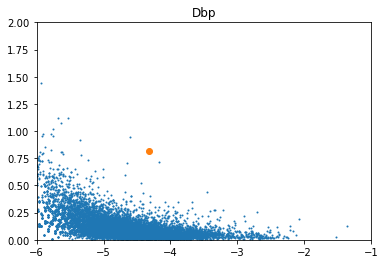

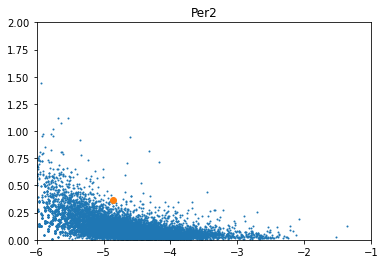

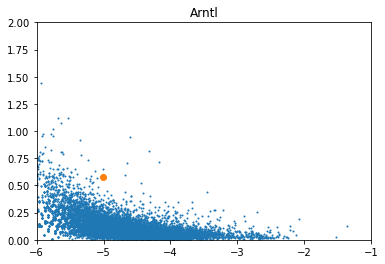

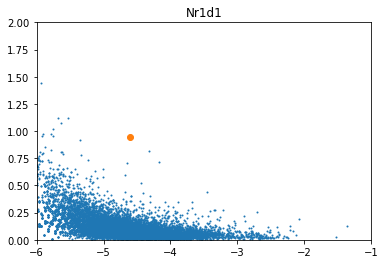

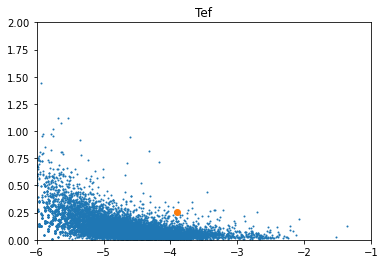

In [69]:


# gene = 'Dbp'
# for gene in ['Dbp', 'Per2','Arntl','Nr1d1','Tef']:
#     plt.clf()
#     plt.scatter(gene_param_df['mesor'] / np.log(10),gene_param_df['amp'] / np.log(10),s=1)
#     plt.scatter(gene_param_df['mesor'].loc[gene] / np.log(10),gene_param_df['amp'].loc[gene] / np.log(10))
#     plt.xlim(-6,-1)
#     plt.ylim(0,2)
#     plt.title(gene)
#     plt.show()




In [79]:
# --- WRITE OUT CONFIG DICT ---


config_dict = {
    "min_prop" : 1e-6,
    "adata_path" : adata_path,
    'hvg_folder' : hvg_folder,
    'scvi_res_folder' : scvi_res_folder,
    'scvi_mean_embedding_df_path' : scvi_mean_embedding_df_path,
    'umap_path_out' : umap_path_out,
    'clustering_folder' : clustering_folder,
    'cluster_df_fileout' : cluster_df_fileout
}


config_out = '%s/config.txt' % reg_head_folder
with open(config_out,'wb') as file_obj:
    file_obj.write(str(config_dict).encode())

